In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy
from scipy.stats import t
from sklearn.linear_model import LinearRegression
from math import sqrt
from matplotlib.patches import Rectangle
from numpy.linalg import inv, qr
from sympy import *
from sympy.plotting import plot3d

## Linear Regression
### Basic Linear Regression
Simple linear regression is a tool used to model the relationship between two continuous variables:
* **Independent Variable (x):** The input variable or feature (the cause or predictor).
* **Dependent Variable (y):** The outcome or target variable we want to predict.
The goal is find the single best fitting straight line through a scatter plot of data points that let us predict the $y$ value for some $x$ value we want to know.

In [2]:
# Import the points
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

# Visualize the data
df.head()

,x,y
0,1,5
1,2,10
2,3,10
3,4,15
4,5,14


In [3]:
# Extract input variables (all the rows, all the columns but last column)
X = df.values[:, :-1]

# Extract output column (all the rows, last column)
Y = df.values[:, -1]

# Fit a line to the points
fit = LinearRegression().fit(X, Y)

m = fit.coef_.flatten()
b = fit.intercept_.flatten()
print("m = {0}".format(m))
print("b = {0}".format(b))

m = [1.93939394]
b = [4.73333333]


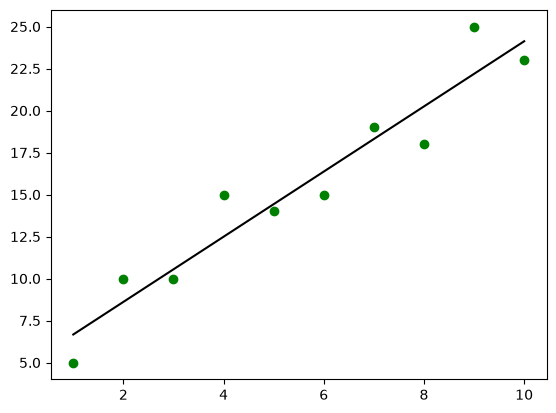

In [4]:
# Show in a chart
plt.plot(X, Y, 'go') # Scatter plot
plt.plot(X, m*X+b, 'black')
plt.show()

---
### Residual and Squared Errors
When we come up with a line that fit to those lines, it comes down to tow questions.
* What defines a best fit? To answer this, we minimize the squares, or more specifically the sum of the squared residuals.

Residual: -1.6727
Residual: 1.3879
Residual: -0.5515
Residual: 2.5091
Residual: -0.4303
Residual: -1.3697
Residual: 0.6909
Residual: -2.2485
Residual: 2.8121
Residual: -1.1273


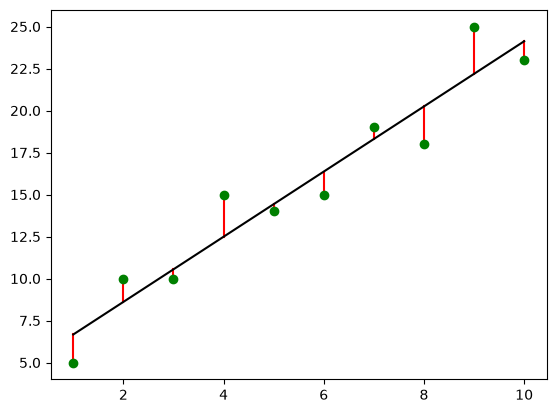

In [5]:
# Import the points
points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

# Test with the line that we get on the last plot
m = 1.93939394
b = 4.73333333

# Plot the scatter points and the regression line
plt.scatter(points['x'], points['y'], color='green', zorder=3)
plt.plot(points['x'], m * points['x'] + b, color='black', zorder=2)

# Calculate the residuals
for p in points.itertuples():
    y_actual =p.y
    y_predict = m*p.x+b
    residual = y_actual - y_predict
    plt.plot([p.x, p.x], [y_actual, y_predict], color='red', linestyle='-', zorder=1)
    print(f'Residual: {residual:.4f}')

plt.show()

The best approach is to take the sum of squares, which simply squares each residual, or multiplies each residual by itself, and sums them. We take each actual y-value and subtract form it the predicted y-value taken from the line, then square and sum all those differences.

In [6]:
# Import the points
points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",").itertuples()

# Test with the line that we get 
m = 1.93939394
b = 4.73333333

sum_of_squares = 0.0

# Calculate sum of squares
for p in points:
    y_actual = p.y
    y_predict = m*p.x + b
    residual_squared = (y_predict - y_actual)**2
    sum_of_squares += residual_squared

print(f"Sum of squares= {sum_of_squares:.4f}")

Sum of squares= 28.0970


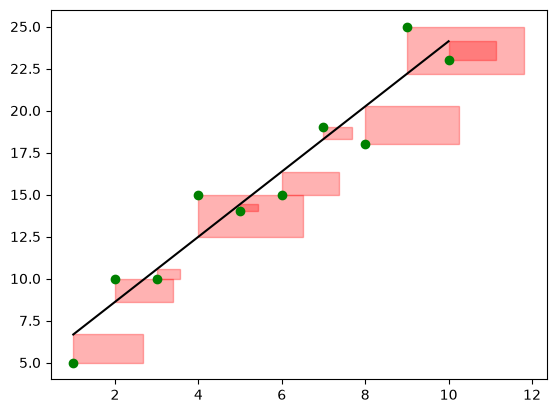

In [7]:
points = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")
m = 1.93939394
b = 4.73333333

plt.scatter(points['x'], points['y'], color='green', zorder=3)
plt.plot(points['x'], m * points['x'] + b, color='black', zorder=2)

for p in points.itertuples():
    res = p.y - (m * p.x + b)
    # Pick the bottom left corner automatically based on the residual sign
    origin = (p.x, m * p.x + b) if res >= 0 else (p.x, p.y)
    
    plt.gca().add_patch(Rectangle(origin, abs(res), abs(res), color='red', alpha=0.3, zorder=1))

plt.show()

---
## Finding the Best Fit Line
The second question that we want to know is how do we find the right $m$ and $b$ values that create the least sum of squares?
We can try to find the right set of values to solve a given problem. We can try brutal force approach, generating random $m$ and $b$ values millions of times and choosing the ones that produce the least sum of squares. But this will not work well because it will take a lot of time to find a decent approximation.

That's why we will need something a little more guided: closed from, matrix inversion, matrix decomposition, gradient descent, and stochastic gradient descent.

---
### Closed Form Equation
For a simple linear regression with only one input and one output variable, here are the closed form equations to calculate $m$ and $b$.
$$m = \frac{n \sum xy - \sum x \sum y}{n \sum x^2 - (\sum x)^2}$$

$$b = \frac{\sum y}{n} - m \frac{\sum x}{n}$$


In [8]:
# Load the data
points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

n = len(points)

m = (n*sum(p.x*p.y for p in points) - sum(p.x for p in points) * 
    sum(p.y for p in points)) / (n*sum(p.x**2 for p in points) -
    sum(p.x for p in points)**2)

b = (sum(p.y for p in points) / n) - m * sum(p.x for p in points) / n

print(m, b)

1.9393939393939394 4.7333333333333325


The reason the closed form equations do not scale well with larger datasets is due to computational complexity.

---
## Notation
In professional data science literature, the linear regression equation $ y = mx + b $ is often written using $\beta$ coefficients:

$$y = \beta_1 x + \beta_0$$
* **$\beta_1$**: Slope ($m$)
* **$\beta_0$**: $y$-intercept ($b$)

---
## Inverse Matrix Techniques
Using linear algebra, we can solve for all regression coefficients simultaneously using matrix operations instead of scalar formulas.

$$b = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

In [9]:
# Import the points 
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

#Extract input variables (all the rows, all the columns but last column)
X = df.values[:, :-1].flatten()

# Add placeholder "1" column to generate intercept
X_1 = np.vstack([X, np.ones(len(X))]).T

# Extract output column (all the rows, last column)
Y = df.values[:, -1]

# Calculate coefficients for slope and intercept
b = inv(X_1.transpose() @ X_1) @ (X_1.transpose() @ Y)
print(b)

# Predict against the y-values
y_predict = X_1.dot(b)

[1.93939394 4.73333333]


When we hae a lot of data with a lot of dimensions, computers can start to choke and produce unstable results. This is a use case for matrix decomposition. 
We take our matrix $X$, append an additional column of $1$ s to generate the intercept $\beta_0$, and then decompose it into two component matrices $Q$ and $R$:

$$ \mathbf{X} = \mathbf{Q} * \mathbf{R} $$

$$\mathbf{b} = \mathbf{R}^{-1} \mathbf{Q}^T \mathbf{y}$$

In [10]:
# Import the points
df = pd.read_csv('https://bit.ly/3goOAnt', delimiter=",")

# Extract the input variables (all the rows, all the columns but last column)
X = df.values[:, :-1]. flatten()

# Add a placeholder "1" column to generate intercept
X_1 = np.vstack([X, np.ones(len(X))]).transpose()

# Extract the output column (all the rows, last column)
Y = df.values[:, -1]

# Calculate coeficiente for slope and intercept using QR decomposition
Q, R = qr(X_1)
b = inv(R). dot(Q.transpose()).dot(Y)

print(b)

[1.93939394 4.73333333]


---
### Gradient Descent
An iterative optimization algorithm that uses derivatives (slopes) to find the parameter values that minimize a loss function.

#### Learning Rate ($L$)
The learning rate determines the step size taking during each iteration:
$$\text{parameter}_{\text{new}} = \text{parameter}_{\text{old}} - (L \times \text{slope})$$
* **Small $L$:** Takes tiny steps. Very accurate, but takes an unacceptably long time to converge.
* **Large $L$:** Takes large steps. Trains quickly, but risks overshooting the minimum and failing to converge.
* **Moderate $L$:** Strikes the optimal balance between computational speed and convergence accuracy.

We optimize the parameters $m$ ($\beta_1$) and $b$ ($\beta_0$) by calculating the partial derivatives of the Sum of Squared Errors loss function:
* Loss Function:
$$E(m, b) = \sum_{i=0}^{n} ((m x_i + b) - y_i)^2$$
* Partial Derivatives:
$$\frac{\partial E}{\partial m} = \sum_{i=0}^{n} 2 x_i (m x_i + b - y_i)$$
$$\frac{\partial E}{\partial b} = \sum_{i=0}^{n} 2 (m x_i + b - y_i)$$

In [11]:
# Import the points from CSV
points = list(pd.read_csv("https://bit.ly/2KF29Bd").itertuples())

# Building the model
m = 0.0
b = 0.0

# Learning Rate
L = 0.001

# The number of iterations
iterations = 100_000

n = float(len(points)) # Number of elements in X

# Perform Gradient Descent
for i in range(iterations):

    # Slope with respect to m
    D_m = sum(2 * p.x * ((m * p.x + b) - p.y) for p in points)

    # Slope with respect to b
    D_b = sum(2 * ((m * p.x + b) - p.y) for p in points)

    # Update m and b
    m -= L * D_m
    b -= L * D_b

print("y = {0}x + {1}".format(m, b))

y = 1.9393939393939548x + 4.733333333333227


Calculating partial derivatives for m and b

In [12]:
m, b, i, n = symbols('m b i n')
x, y = symbols('x y', cls=Function)
sum_of_squares = Sum((m*x(i) + b - y(i)) ** 2, (i, 0, n))
d_m = diff(sum_of_squares, m)
d_b = diff(sum_of_squares, b)
print(d_m)
print(d_b)

Sum(2*(b + m*x(i) - y(i))*x(i), (i, 0, n))
Sum(2*b + 2*m*x(i) - 2*y(i), (i, 0, n))


Solving linear regression using NumPy

In [13]:
# Load data directly into NumPy arrays
df = pd.read_csv("https://bit.ly/2KF29Bd")
x_vals = df['x'].to_numpy()
y_vals = df['y'].to_numpy()

# Initialize model parameters
m = 0.0
b = 0.0

# Hyperparameters
L = 0.001
iterations = 100_000

# Perform Gradient Descent (Vectorized)
for _ in range(iterations):
    # Calculate predictions
    y_pred = m * x_vals + b

    # Calculate partial derivatives using array operations
    D_m = np.sum(2 * (y_pred - y_vals) * x_vals)
    D_b = np.sum(2 * (y_pred - y_vals))

    #Update m and b
    m -= L * D_m
    b -= L * D_b
print(f"y = {m}x + {b}")

y = 1.9393939393939548x + 4.733333333333227


Plotting the loss function for linear regression

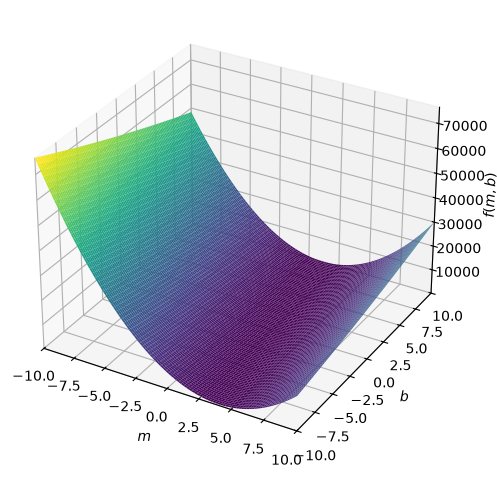

In [14]:
# Import the points
points = list(pd.read_csv("https://bit.ly/2KF29Bd").itertuples())
# Define symbolic variables for parameters
m, b, i, n = symbols('m b i n')
x, y = symbols('x y', cls=Function)
# Construct the Sum of Squared Errors symbolic equation
sum_of_squares = Sum((m*x(i) + b - y(i)) ** 2, (i, 0, n)) \
    .subs(n, len(points) - 1).doit() \
    .replace(x, lambda i: points[i].x) \
    .replace(y, lambda i: points[i].y)
# Render the 3D plot
plot3d(sum_of_squares)

---
### Overfitting and High Variance
Minimizing loss down to zero (such as connecting data points directly with line segments) creates an overfit model. Rather than learning underlying general patterns, an overfit model simply memorizes the training dataset.

Because it bends to fit every noise point and outlier, ti suffers from high variance, meaning its predictions fluctuate wildly and perform poorly when introduced to new, unseen data.

--- 
### Model Bias
To prevent memorization, machine learning algorithms introduce model bias. Model bias refers to the structural constrains we place on an algorithm, such as forcing a regression model to maintain a straight lien rather than curving around every point.

Adding model bias intentionally increases underfitting on training data, providing the necessary "wiggle room" for the model to generalize effectively to new inputs.

---
### Regularization Techniques
To prevent overfitting in linear models, regularized variants add extra bias penalties:
* **Ridge Regression:** Adds a further bias to a linear regression in the form of a penalty, therefore causing it to fit less to the data.
* **Lasso Regression:** Will attempt to marginalize noisy variables, making it useful when you want to automatically remove variables that might be irrelevant.

---
### Stochastic Gradient Descent
Gradient descent variants differ primarily in how much data is used to calculate the gradient on each iteration:
*  **Batch Gradient Descent:** Uses the entire dataset per iteration. It is computationally expensive and tends to settle deeply into the loss landscape, increasing the risk of overfitting.
* **Stochastic Gradient Descent (SGD):** Uses a single random data sample per iteration. It drastically reduces computation and introduces noise into the loss landscape acting as a for of regularization that helps prevent overfitting.
* **Mini-Batch Gradient Descent:** Uses a small subset of data (e.g., 10 to 100 points) per iteration, striking a practical balance between computational efficiency, training stability and generalization ability.

In [15]:
# Input the data
data = pd.read_csv('https://bit.ly/2KF29Bd', header=0)

X = data.iloc[:, 0].values
Y = data.iloc[:, 1].values

n = data.shape[0] # Rows

# Building the model
m = 0.0
b = 0.0

sample_size = 1 # Sample size
L = 0.0001 # Learning Rate
epochs = 1_000_000 # The number of iterations to perform gradient descent

# Performing Stochastic Gradient Descent
for i in range(epochs):
    idx = np.random.choice(n, sample_size, replace=False)
    x_sample = X[idx]
    y_sample = Y[idx]

    # The current predicted value of Y
    Y_pred = m * x_sample + b

    # d/dm derivative of loss function
    D_m = (-2 / sample_size) * sum(x_sample * (y_sample - Y_pred))

    # d/db derivative of loss function
    D_b = (-2 / sample_size) * sum(y_sample - Y_pred)
    m = m - L * D_m # Update m
    b = b - L * D_b # Update b

    # print progress
    if i % 10000 == 0:
        print(i, m, b)

print("y = {0}x + {1}".format(m, b))

0 0.014 0.0028
10000 2.3470614300401027 1.8446067057038444
20000 2.2410204124303275 2.8373977560689916
30000 2.120509517418853 3.479547227824211
40000 2.104831412575884 3.9018903857700615
50000 2.020508489194498 4.180397381424971
60000 1.9907819888303464 4.356296797145814
70000 1.9351377665763922 4.478656643435543
80000 1.9321239478518537 4.58142365915444
90000 1.943391144244862 4.647489622963335
100000 1.9423455364242748 4.692124177770857
110000 1.9315662534409679 4.702572108415962
120000 1.946956067991059 4.702472366729409
130000 1.927898271235035 4.715327403973696
140000 1.9415244817431845 4.720491098172008
150000 1.9733233586644903 4.731030323327908
160000 1.9150680125509079 4.741755154917325
170000 1.9469089423306771 4.749005638265805
180000 1.9246827645473805 4.748281391097989
190000 1.9209080255575945 4.75784263519547
200000 1.952737687398577 4.748688158682816
210000 1.917872640735703 4.731872333162376
220000 1.9383942611238103 4.739108125270962
230000 1.9651292295657947 4.73293

---
### Correlation Coefficient
The correlation coefficient, also called the Pearson correlation, which measures the strength of the relationship between two variables as a value between $-1$ and $1$.

A correlation coefficient closer to $0$ indicates there is no correlation. A correlation coefficient closer to $1$ indicates a strong positive correlation, meaning when one variable increases, the other proportionally increases. If it is closer to $-1$ then it indicates a strong negative correlation, which menas as one variable increases the other proportionally decreases.

In [16]:
# Read data into Pandas dataframe
df = pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",")

# Print correlations between variables
correlations = df.corr(method='pearson')
print(correlations)

          x         y
x  1.000000  0.957586
y  0.957586  1.000000


If we want to calculate mathematically the correlation coefficient, here is the formula:
$$r = \frac{n \sum xy - (\sum x)(\sum y)}{\sqrt{n \sum x^2 - (\sum x)^2} \sqrt{n \sum y^2 - (\sum y)^2}}$$

In [17]:
# Import the points form CSV
points = list(pd.read_csv("https://bit.ly/2KF29Bd").itertuples())
n = len(points)

numerator = n * sum(p.x * p.y for p in points) - sum(p.x for p in points) * sum(p.y for p in points)

denominator = sqrt(n*sum(p.x**2 for p in points) - sum(p.x for p in points)**2) * sqrt(n*sum(p.y**2 for p in points) - sum(p.y for p in points)**2)

corr = numerator / denominator
print(corr)


80*sqrt(3102)/4653


---
### Statistical Significance
How can we be 95% sure the correlation between these two variables is significant and not coincidental?. We need to not just express the correlation coefficient but also quantify ho confident we are that the correlation coefficient did not occur by chance.

We denote the population correlation coefficient with the symbol $\rho$ while our sample correlation coefficient is $r$.

$$H_0: \rho = 0 \quad \text{(implies no relationship)}$$
$$H_1: \rho \neq 0 \quad \text{(relationship is present)}$$

We use a T-distribution rather than a normal distribution to do hypothesis testing with linear regression. First, let's plot a T-distribution with a 95% critical value range. We account for the fat there are 10 records in our sample and therefore we haver 9 degrees of freedom $(10 - 1 = 9)$ 

In [18]:
n = 10
lower_cv = t(n-1).ppf(.025)
upper_cv = t(n-1).ppf(.975)

print(lower_cv, upper_cv)

-2.2621571627982053 2.262157162798205


If our test value happens to fall outside this range of $(-2.262, 2.262)$, then we can reject our null hypothesis. To calculate the test value $t$, we need to use the following formula. 
$$t = \frac{r}{\sqrt{\frac{1-r^2}{n-2}}}$$

$$t = \frac{.957586}{\sqrt{\frac{1-.957586^2}{10-2}}} = 9.339956$$

In [19]:
n = 10
lower_cv = t(n-1).ppf(.025)
upper_cv = t(n-1).ppf(.975)
# Correlation coefficient

# Derived from data
r = 0.957586

# Perform the test
test_value = float(r / sqrt((1-r**2) / (n-2)))
print("TEST VALUE: {}".format(test_value))
print("CRITICAL RANGE: {}, {}".format(lower_cv, upper_cv))

if test_value < lower_cv or test_value > upper_cv:
    print("CORRELATION PROVEN, REJECT H0")
else:
    print("CORRELATION NOT PROVEN, FAILED TO REJECT H0 ")

# Calculate p-value
if test_value > 0:
    p_value = 1.0 - t(n-1).cdf(test_value)
else:
    p_value = t(n-1).cdf(test_value)

# Two-tailed, so multiply by 2
p_value = p_value * 2
print("P-Value: {}".format(p_value))

TEST VALUE: 9.399564671312076
CRITICAL RANGE: -2.2621571627982053, 2.262157162798205
CORRELATION PROVEN, REJECT H0
P-Value: 5.9763860877914965e-06


---
### Coefficient of Determination
The coefficient of determination, called $r^2$, measures how much variation in one variable is explainable by the variation of the other variable. Essentially, $r^2$ shows how much two variables interact with each other.

In [20]:
# Read data into Pandas dataframe
df = pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",")

# Print correlations between variables
coeff_determination = df.corr(method='pearson')**2
print(coeff_determination)

          x         y
x  1.000000  0.916971
y  0.916971  1.000000


---
### Standard Error of the Estimate
One way to measure the overall error of a linear regression is the SSE (sum of squared error).
$$ SSE = \sum{(y - \hat{y})^2}$$

All of these squared values are hard to interpret so we can use some square root logic to scale things back into the original units. We will also average all of them, and this is what the standard error of the estimate($S_e$) does.
$$S_e = \frac{\sum (y_i - \hat{y}_i)^2}{n - 2}$$


In [21]:
# Load the data
points = list(pd.read_csv('https://bit.ly/2KF29Bd', delimiter=",").itertuples())

n = len(points)

# Regression line
m = 1.939
b = 4.733

# Calculate Standard Error of Estimate
S_e = sqrt((sum((p.y - (m*p.x +b))**2 for p in points))/(n-2))

print(S_e)


1.87406793500129


---
## Summary
- Linear regression finds the best-fit line to model relationships between variables
- Correlation measures strength of linear relationships, not causation
- Hypothesis testing and p-values determine if correlations are statistically significant
- R² and standard error quantify how well the model explains the data